## 🔗 Data Sources & References

The **Occupation Shortage Forecaster** project utilizes official public data from the Australian Government, integrating datasets from various employment and immigration portals.

🏢 **1. JSA Rating - Skills Priority List - Jobs and Skills Australia (JSA)**
> Used to determine the current official status of an occupation in each state (*Shortage, Regional Shortage, or No Shortage*).
> * **Link:** [JSA Skills Priority List Data](https://www.jobsandskills.gov.au/sites/default/files/2023-11/skills_priority_list_occupation_list.pdf)
> * **Original Format:** PDF

🌐 **2. EOI Activity - SkillSelect Dashboards - State Governments**
> Used to aggregate monthly *Expression of Interest* (EOI) submissions from prospective migrant workers as a direct proxy for labor supply per state.
> * **Link:** [Skill Select Dashboard](https://api.dynamic.reports.employment.gov.au/anonap/extensions/hSKLS02_SkillSelect_EOI_Data/hSKLS02_SkillSelect_EOI_Data.html)
> * **Original Format:** Web Portal / Web Scraped CSV

📈 **3. Employment Growth - Employment Projections - Jobs and Skills Australia (JSA)**
> Used to obtain 5-year employment growth projections categorized by ANZSCO Codes to anticipate mid-to-long-term market trends.
> * **Link:** [Australian Employment Projections](https://www.jobsandskills.gov.au/data/employment-projections)
> * **Original Format:** Web Portal / Excel File

⏳ **4. OSL Data - Historical Shortage List - Jobs and Skills Australia (JSA)**
> Used to extract historical Occupation Shortage List (OSL) data from 2021–2025 across states to track past shortage behaviors and recovery periods.
> * **Link:** [Historical Shortage List](https://www.jobsandskills.gov.au/data/occupation-shortage/occupation-shortage-list)
> * **Original Format:** Web Portal / CSV File

# 1. Import Library

In [41]:
# ==========================================
# CELL 1: IMPORT & KONFIGURASI
# ==========================================
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, brier_score_loss

# Konfigurasi Path
base_path = 'C:/Users/Gustu/Documents/MAGANG INTERLACE/data-analyst/' # Sesuaikan dengan path Anda

# Konfigurasi Parameter Global
HISTORICAL_YEARS = [2021, 2022, 2023, 2024, 2025]
FORECAST_YEARS = [2026, 2027, 2028, 2029, 2030]
STATES = ['NSW', 'VIC', 'QLD', 'SA', 'WA', 'TAS', 'NT', 'ACT']

print("Cell 1 Executed: Library imported and paths configured.")

Cell 1 Executed: Library imported and paths configured.


# 2. Load Historical Data (OSL)

In [ ]:
# ==========================================
# CELL 2: LOAD DATA OSL (HISTORICAL)
# ==========================================
osl_list = []

for year in HISTORICAL_YEARS:
    # Menggabungkan path dinamis sesuai tahun
    # Sesuaikan dengan nama file Anda
    file_path = os.path.join(base_path, f"scraping-occupation-shortage-list/DATASET/cleaned_data/OSL {year} (ANZSCO 6)_Cleaned.csv") 
    df = pd.read_csv(file_path)
    
    # Transformasi State dari kolom ke baris (Melting)
    df_melt = df.melt(id_vars=['Code', 'Occupation'], value_vars=STATES, 
                      var_name='State', value_name='is_shortage')
    df_melt['Year'] = year
    osl_list.append(df_melt)

# Gabungkan semua tahun dan urutkan
df_osl = pd.concat(osl_list).sort_values(['Code', 'State', 'Year']).reset_index(drop=True)

print(f"OSL Data Loaded: {df_osl.shape[0]} rows.")
display(df_osl.head(5))

OSL Data Loaded: 35888 rows.


,Code,Occupation,State,is_shortage,Year
0,111111,Chief Executive or Managing Director,ACT,0,2021
1,111111,Chief Executive or Managing Director,ACT,0,2022
2,111111,Chief Executive or Managing Director,ACT,0,2023
3,111111,Chief Executive or Managing Director,ACT,0,2024
4,111111,Chief Executive or Managing Director,ACT,0,2025


# 3. Load Data JSA & Projections

In [ ]:
# ==========================================
# CELL 3: LOAD JSA & PROJECTIONS 
# ==========================================
# 1. Load JSA Ratings
# Sesuaikan dengan nama file Anda
jsa_path = os.path.join(base_path, 'scraping-occupation-shortage-list/DATASET/additional_data/JSA_Skills_Priority_List_Cleaned.csv')
df_jsa = pd.read_csv(jsa_path, sep=';')

# Bersihkan Code JSA (Ubah ke angka utuh, lalu ke text)
df_jsa['Code'] = pd.to_numeric(df_jsa['Code'], errors='coerce').fillna(0).astype(int).astype(str)

jsa_map = {'S': 1.0, 'R': 0.5, 'NS': 0.0}

# 2. Load Employment Projections
# Sesuaikan dengan nama file Anda
proj_path = os.path.join(base_path, 'scraping-occupation-shortage-list/DATASET/additional_data/Processed_Employment_Projections.csv')
df_proj = pd.read_csv(proj_path)

# BERSIIHKAN FLOAT DI PROYEKSI (Ubah 1111.0 -> 1111 -> "1111")
df_proj['ANZSCO_Code'] = pd.to_numeric(df_proj['ANZSCO_Code'], errors='coerce').fillna(0).astype(int).astype(str)

print("JSA Data Loaded:")
display(df_jsa.head(3))
print("Employment Projections Loaded:")
display(df_proj.head(3))

JSA Data Loaded:


,Code,Occupation,JSA_Rating_AUS,JSA_Rating_NSW,JSA_Rating_VIC,JSA_Rating_QLD,JSA_Rating_SA,JSA_Rating_WA,JSA_Rating_TAS,JSA_Rating_NT,JSA_Rating_ACT,Future_Demand
0,132111,Corporate Services Manager,S,S,S,S,S,S,S,S,S,Strong
1,135112,ICT Project Manager,S,S,S,S,S,S,S,S,S,Strong
2,139914,Quality Assurance Manager,S,S,S,S,S,S,S,S,S,Strong


Employment Projections Loaded:


,Occupation_Level,NFD_Indicator,ANZSCO_Code,Occupation,Skill_Level,Baseline_2025,Projected_2030,Projected_2035,Level_5Y_Change,Pct_5Y_Change,Level_10Y_Change,Pct_10Y_Change
0,4,Y,1000,Managers nfd,1,6.156358,6.734914,7.201743,0.578556,0.093977,1.045385,0.169806
1,4,Y,1110,"Chief Executives, General Managers and Legisla...",1,0.152154,0.166575,0.178509,0.014421,0.094780,0.026355,0.173211
2,4,N,1111,Chief Executives and Managing Directors,1,61.193147,65.387754,69.815600,4.194606,0.068547,8.622453,0.140906


# 4. Load Data EOI Activity

In [ ]:
# ==========================================
# CELL 4: LOAD EOI ACTIVITY
# ==========================================
eoi_dir = os.path.join(base_path, 'EOI-activity-scraping/DATASET_SUBMISSION_LATEST_MONTH/') # Sesuaikan dengan nama folder Anda
eoi_files = [f for f in os.listdir(eoi_dir) if f.startswith('EOI_Submission_Activity_') and f.endswith('.csv')]
eoi_list = []

def clean_eoi_count(val):
    if pd.isna(val): return 0
    val = str(val).strip()
    if val == '<20': return 10 
    try: return float(val.replace(',', ''))
    except: return 0

for f in eoi_files:
    file_path = os.path.join(eoi_dir, f)
    temp_eoi = pd.read_csv(file_path)
    
    # Ekstrak 6 digit pertama
    temp_eoi['Code'] = temp_eoi['Occupation'].str.extract(r'^(\d{6})')[0]
    
    # FIX: Paksa jadi Angka Utuh -> String
    temp_eoi['Code'] = pd.to_numeric(temp_eoi['Code'], errors='coerce').fillna(0).astype(int).astype(str)
    
    temp_eoi['Count'] = temp_eoi['Count EOIs'].apply(clean_eoi_count)
    eoi_list.append(temp_eoi[['Code', 'State', 'Count']])

if len(eoi_list) > 0:
    df_eoi = pd.concat(eoi_list).groupby(['Code', 'State'])['Count'].sum().reset_index()
else:
    df_eoi = pd.DataFrame(columns=['Code', 'State', 'Count'])

print(f"EOI Data Loaded & Aggregated: {df_eoi.shape[0]} unique Code-State combinations.")
display(df_eoi.head(5))

EOI Data Loaded & Aggregated: 3359 unique Code-State combinations.


,Code,State,Count
0,121111,ACT,20.0
1,121111,NSW,60.0
2,121111,NT,50.0
3,121111,QLD,30.0
4,121111,SA,30.0


# 5. Feature Engineering

In [45]:
# ==========================================
# CELL 5: FEATURE ENGINEERING (FIXED MAPPING)
# ==========================================
feature_map = {}

# FIX: Pastikan kode OSL dikonversi menjadi Integer -> String utuh (Sangat Penting!)
df_osl['Code'] = pd.to_numeric(df_osl['Code'], errors='coerce').fillna(0).astype(int).astype(str)

for code_str in df_osl['Code'].unique():
    # Ambil 4 digit pertama untuk mencocokkan dengan data Proyeksi yang hanya punya 4 digit
    code_4_digit = code_str[:4] 
    
    for state in STATES:
        # A. JSA Rating (6-digit match)
        jsa_val = 0
        jsa_row = df_jsa[df_jsa['Code'] == code_str]
        if not jsa_row.empty:
            col_name = f'JSA_Rating_{state}'
            if col_name in jsa_row.columns:
                jsa_val = jsa_map.get(jsa_row[col_name].iloc[0], 0)
        
        # B. Employment Growth (Coba 6-digit, jika gagal coba 4-digit)
        growth_val = 0
        proj_row = df_proj[df_proj['ANZSCO_Code'] == code_str]
        if proj_row.empty:
            proj_row = df_proj[df_proj['ANZSCO_Code'] == code_4_digit]
            
        if not proj_row.empty:
            growth_val = proj_row['Pct_5Y_Change'].iloc[0]
            
        # C. EOI Activity (6-digit match)
        eoi_val = 0
        eoi_row = df_eoi[(df_eoi['Code'] == code_str) & (df_eoi['State'] == state)]
        if not eoi_row.empty:
            eoi_val = eoi_row['Count'].iloc[0]
            
        feature_map[(code_str, state)] = (jsa_val, growth_val, eoi_val)

train_data = []

for (code, state), group in df_osl.groupby(['Code', 'State']):
    shortages = group.sort_values('Year')['is_shortage'].values
    
    # Mulai dari prediksi tahun 2022 (indeks 1)
    for i in range(1, len(shortages)):
        hist = shortages[:i] 
        streak = 0
        for s in reversed(hist):
            if s == 1: streak += 1
            else: break
        count_5yr = sum(hist[-5:])
        
        jsa_v, growth_v, eoi_v = feature_map.get((code, state), (0,0,0))
        
        train_data.append({
            'shortage_streak': streak,
            'shortage_count_5yr': count_5yr,
            'employment_growth': growth_v,
            'jsa_rating': jsa_v,
            'eoi_activity': eoi_v,
            'target': shortages[i]
        })

df_train = pd.DataFrame(train_data)
print(f"Dataset Training siap!")
display(df_train.head(10))

Dataset Training siap!


,shortage_streak,shortage_count_5yr,employment_growth,jsa_rating,eoi_activity,target
0,0,0,0.068547,0.0,0.0,0
1,0,0,0.068547,0.0,0.0,0
2,0,0,0.068547,0.0,0.0,0
3,0,0,0.068547,0.0,0.0,0
4,0,0,0.068547,0.0,0.0,0
5,0,0,0.068547,0.0,0.0,0
6,0,0,0.068547,0.0,0.0,0
7,0,0,0.068547,0.0,0.0,0
8,0,0,0.068547,0.0,0.0,0
9,0,0,0.068547,0.0,0.0,1


# 6. Model Training, Calibration, & Evaluasi

HASIL EVALUASI MODEL (VALIDATION DATA)

1. CLASSIFICATION REPORT:
                 precision    recall  f1-score   support

No Shortage (0)       0.88      0.91      0.89      3712
   Shortage (1)       0.82      0.77      0.79      2000

       accuracy                           0.86      5712
      macro avg       0.85      0.84      0.84      5712
   weighted avg       0.86      0.86      0.86      5712

2. PROBABILITY METRICS:
Brier Score   : 0.1068  (Mendekati 0 = Sangat Baik)
ROC-AUC Score : 0.9046  (Mendekati 1 = Sangat Baik)



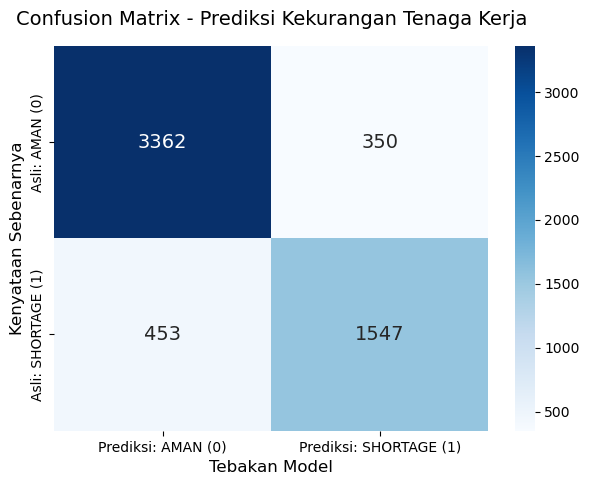


Melatih ulang model menggunakan 100% dataset historis untuk persiapan Forecasting...
✅ Model Final siap digunakan untuk Forecasting di Cell 7!


In [46]:
# ==========================================
# CELL 6: TRAINING MODEL, EVALUASI & RETRAIN 
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, brier_score_loss, roc_auc_score

# 1. Tentukan Fitur dan Target
features = ['shortage_streak', 'shortage_count_5yr', 'employment_growth', 'jsa_rating', 'eoi_activity']
X = df_train[features]
y = df_train['target']

# 2. Split data (80% Train, 20% Val) untuk Evaluasi secara proporsional (stratify)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Inisialisasi Model & Kalibrator
rf_base = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)
model = CalibratedClassifierCV(rf_base, method='sigmoid', cv=5)

# 4. Latih Model pada data Training (80%)
model.fit(X_train, y_train)

# 5. Prediksi pada data Validasi (20%)
y_pred_class = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]

# ==========================================
# EVALUASI 1: METRIK STATISTIK & CLASSIFICATION REPORT
# ==========================================
print("="*50)
print("HASIL EVALUASI MODEL (VALIDATION DATA)")
print("="*50)

# Classification Report
print("\n1. CLASSIFICATION REPORT:")
print(classification_report(y_val, y_pred_class, target_names=['No Shortage (0)', 'Shortage (1)']))

# Metrik Probabilitas
brier = brier_score_loss(y_val, y_pred_proba)
roc_auc = roc_auc_score(y_val, y_pred_proba)

print("2. PROBABILITY METRICS:")
print(f"Brier Score   : {brier:.4f}  (Mendekati 0 = Sangat Baik)")
print(f"ROC-AUC Score : {roc_auc:.4f}  (Mendekati 1 = Sangat Baik)\n")

# ==========================================
# EVALUASI 2: VISUALISASI CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_val, y_pred_class)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prediksi: AMAN (0)', 'Prediksi: SHORTAGE (1)'],
            yticklabels=['Asli: AMAN (0)', 'Asli: SHORTAGE (1)'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix - Prediksi Kekurangan Tenaga Kerja', fontsize=14, pad=15)
plt.xlabel('Tebakan Model', fontsize=12)
plt.ylabel('Kenyataan Sebenarnya', fontsize=12)
plt.show()

# ==========================================
# TAHAP FINAL: RETRAIN UNTUK PRODUKSI
# ==========================================
print("\nMelatih ulang model menggunakan 100% dataset historis untuk persiapan Forecasting...")
model.fit(X, y)
print("✅ Model Final siap digunakan untuk Forecasting di Cell 7!")

# 7. Recursive Forecasting (2026 - 2030)

In [ ]:
# ==========================================
# CELL 7: RECURSIVE FORECASTING DENGAN DINAMIKA PASAR
# ==========================================
current_histories = df_osl.groupby(['Code', 'State'])['is_shortage'].apply(list).to_dict()
occ_names = df_osl.set_index('Code')['Occupation'].to_dict()

forecast_results = []

for forecast_year in FORECAST_YEARS:
    batch_features = []
    keys = []
    
    # Menghitung jarak tahun dari 2026 (0, 1, 2, 3, 4)
    year_gap = forecast_year - 2026 
    
    for (code, state), history in current_histories.items():
        # Fitur Dinamis
        streak = 0
        for v in reversed(history):
            if v == 1: streak += 1
            else: break
        count_5yr = sum(history[-5:])
        
        # Fitur Statis
        jsa_v, growth_v, eoi_v = feature_map.get((code, state), (0,0,0))
        
        # -------------------------------------------------------------
        # ✨ MARKET DYNAMICS SIMULATION ✨
        # 1. EOI menyusut 15% setiap tahun (karena kuota visa terpenuhi)
        simulated_eoi = eoi_v * (0.85 ** year_gap) 
        
        # 2. Growth melandai 5% setiap tahun ke arah netral
        simulated_growth = growth_v * (0.95 ** year_gap)
        # -------------------------------------------------------------
        
        batch_features.append([streak, count_5yr, simulated_growth, jsa_v, simulated_eoi])
        keys.append((code, state))
        
    df_batch = pd.DataFrame(batch_features, columns=features)
    probs = model.predict_proba(df_batch)[:, 1]
    
    for i, (code, state) in enumerate(keys):
        p = probs[i]
        forecast_results.append({
            'Code': code,
            'Occupation': occ_names.get(code, "N/A"),
            'State': state,
            'Year': forecast_year,
            'Shortage_Probability': round(p, 4)
        })
        current_histories[(code, state)].append(1 if p > 0.45 else 0)

# (Lanjutkan dengan kode Pivot Table seperti sebelumnya di bawah sini)
df_forecast_long = pd.DataFrame(forecast_results)
df_forecast_wide = df_forecast_long.pivot_table(
    index=['Code', 'Occupation', 'State'], 
    columns='Year', 
    values='Shortage_Probability'
).reset_index()
df_forecast_wide.columns.name = None
df_forecast_wide = df_forecast_wide.rename(columns={
    2026: 'Prob_2026', 2027: 'Prob_2027', 2028: 'Prob_2028', 
    2029: 'Prob_2029', 2030: 'Prob_2030'
})
df_forecast_wide = df_forecast_wide.sort_values(by=['State', 'Prob_2026'], ascending=[True, False]).reset_index(drop=True)

display(df_forecast_wide.head(15))

# 4. Simpan output ke CSV
# Sesuaikan dengan nama file output yang Anda inginkan
output_path = os.path.join(base_path, 'scraping-occupation-shortage-list/DATASET/result_data/Occupation_Shortage_Forecaster_2026_2030_Wide.csv')
df_forecast_wide.to_csv(output_path, index=False)

print(f"\n✅ FORECASTING SELESAI! Hasil yang lebih rapi tersimpan di:\n{output_path}")

,Code,Occupation,State,Prob_2026,Prob_2027,Prob_2028,Prob_2029,Prob_2030
0,251214,Sonographer,ACT,0.7940,0.7581,0.5751,0.5077,0.5977
1,323212,Fitter and Turner,ACT,0.7922,0.7618,0.7897,0.7877,0.7906
2,252511,Physiotherapist,ACT,0.7920,0.7913,0.7348,0.6721,0.5313
3,322311,Metal Fabricator,ACT,0.7920,0.7580,0.7867,0.7811,0.7829
4,321111,Automotive Electrician,ACT,0.7918,0.7917,0.7914,0.7521,0.7832
5,322313,Welder (First Class),ACT,0.7915,0.7638,0.7891,0.7864,0.7900
6,331111,Bricklayer,ACT,0.7912,0.7879,0.7853,0.7876,0.7893
7,332211,Painter,ACT,0.7910,0.7885,0.7881,0.7897,0.7912
8,252411,Occupational Therapist,ACT,0.7907,0.7320,0.6673,0.5372,0.5585
9,252311,Dental Specialist,ACT,0.7906,0.7325,0.7500,0.6848,0.5792



✅ FORECASTING SELESAI! Hasil yang lebih rapi tersimpan di:
C:/Users/Gustu/Documents/MAGANG INTERLACE/data-analyst/scraping-occupation-shortage-list/DATASET/result_data/Occupation_Shortage_Forecaster_2026_2030_Wide.csv
